# SECOM Data Modeling
---

### Imports and creating test-train split

In [73]:
# Imports
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from xgboost import XGBClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
import warnings

In [74]:
# silencing nuissance warnings
warnings.filterwarnings("ignore")

In [75]:
# Pulling in the SECOM data and loading data into feature and label dataframes
secom = fetch_ucirepo(id=179)
df = pd.DataFrame(secom.data.original)
X = df.drop(columns=["class", "timestamp"])
y = df["class"]
# converting "-1" passing label to "0"
y = y.replace(-1, 0)

In [76]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

class
0    0.933759
1    0.066241
Name: proportion, dtype: float64
class
0    0.933121
1    0.066879
Name: proportion, dtype: float64


___

### Creating custom Secom dataset preprocess transformer

In [78]:
class SecomPreProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, missing_threshold: int, corr_threshold: int):
        self.missing_threshold = missing_threshold
        self.corr_threshold = corr_threshold

    def fit(self, X: pd.DataFrame, y=None):
        X = X.copy()

        # filtering out features with null percentage above threshold
        self.null_cols_ = X.columns[X.isna().mean() > self.missing_threshold].to_list()
        X = X.drop(columns=self.null_cols_)
        
        # imputing NaN with median
        self.medians_ = X.median()
        X = X.fillna(self.medians_)

        # Remove constant variance features
        self.zero_var_cols_ = X.columns[X.var() == 0].to_list()
        X = X.drop(columns=self.zero_var_cols_)

        # dropping columns correlated above threshold
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

        self.corr_cols_ = [
            col
            for col in upper.columns
            if any(upper[col] > self.corr_threshold)
        ]

        X = X.drop(columns=self.corr_cols_)

        self.feature_names_out_ = X.columns.to_list()

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        X = X.drop(
            columns=self.null_cols_ + self.zero_var_cols_ + self.corr_cols_,
            errors="ignore"
        )

        X = X.fillna(self.medians_)

        if list(X.columns) != self.feature_names_out_:
            raise ValueError("Transformed columns do not match fitted columns.")

        return X

    def get_feature_names_out(self, input_features=None) -> np.array:
        return np.array(self.feature_names_out_)

___

### Custom PLSTransformer 
Needed since it returns X and y arrays, where models such as logistic regression expect only X.
This PLSTransformer is simply a custom transformer wrapper around PLSRegression to capture the X array of latent variables to be used in subsequent modeling.

In [79]:
# Creating custom transformer to extract PLS componenets
class PLSTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=10):
        self.n_components = n_components

    def fit(self, X, y):
        self.pls_ = PLSRegression(n_components=self.n_components)
        self.pls_.fit(X, y)
        return self

    def transform(self, X):
        return self.pls_.transform(X)

___

### Creating a loop to test the performance of several models at once

In [80]:
# specifying dictionaries with two categories of models: ones that need scaling and those that do not (typically tree-based models)
models_needs_scaling = {
    "Logistic Regression": LogisticRegression(
        penalty='l1', 
        random_state=42, 
        class_weight="balanced", 
        solver='liblinear', 
        max_iter=5000        
    ),
    "SVM Linear": SVC(
        kernel="linear",
        C=1.0,
        class_weight="balanced",
        probability=True,
        random_state=42
    ),
    "SVM RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    )
}
models_no_scaling = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (small)": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Histogram Gradient Boost": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        eval_metric="logloss"
    )
}

In [81]:
# Adding this custom pipeline dictionary as the PLS modeling is a special case as it needs the special PLSTransformer we created
models_custom_pipelines = {
    f"PLS-DA {n} components": Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("scale", StandardScaler()),
        ("pls", PLSTransformer(n_components=n)),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])
    for n in [2, 5, 10, 15, 20, 30]
}

In [82]:
# creating a function to run cross validation on multiple models at once and storing otputting their performance to a dataframe
def run_performance(models_needs_scaling: dict, models_no_scaling: dict, models_custom_pipelines: dict | None = None, 
                    X_train : pd.DataFrame = X_train, y_train: pd.DataFrame = y_train) -> pd.DataFrame:
    results = []

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def evaluate_pipe(name, pipe):
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "pr_auc": "average_precision"
            },
            return_train_score=True,
            n_jobs=-1
        )

        results.append({
            "model": name,
            "train_roc_auc": scores["train_roc_auc"].mean(),
            "train_pr_auc": scores["train_pr_auc"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_roc_auc_std": scores["test_roc_auc"].std(),
            "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
            "cv_pr_auc_std": scores["test_pr_auc"].std(),
        })


    for name, model in models_needs_scaling.items():
        pipe = Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("scale", StandardScaler()),
        ("model", model)
        ])

        evaluate_pipe(name, pipe)
        

    for name, model in models_no_scaling.items():
        pipe = Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("model", model)
        ])

        evaluate_pipe(name, pipe)

    if models_custom_pipelines is not None:
        for name, pipe in models_custom_pipelines.items():
            evaluate_pipe(name, pipe)

    performance_summary = pd.DataFrame(results).sort_values("cv_pr_auc_mean", ascending=False).reset_index(drop=True)
    return performance_summary

In [83]:
# Running performance checks
performance_summary = run_performance(models_needs_scaling=models_needs_scaling, models_no_scaling=models_no_scaling, 
                                      models_custom_pipelines=models_custom_pipelines)
performance_summary

,model,train_roc_auc,train_pr_auc,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,Random Forest (small),1.000000,1.000000,0.724020,0.048940,0.200041,0.052828
1,Random Forest,1.000000,1.000000,0.722766,0.054694,0.198035,0.059456
2,XGBoost,1.000000,1.000000,0.698303,0.063096,0.194247,0.048157
3,PLS-DA 2 components,0.901980,0.529548,0.662689,0.058279,0.161826,0.057569
4,PLS-DA 5 components,0.944674,0.702331,0.646732,0.037519,0.153672,0.052328
5,Logistic Regression,0.998701,0.970597,0.599604,0.082212,0.153012,0.079866
6,SVM Linear,0.999822,0.994890,0.577256,0.077944,0.148724,0.075724
7,SVM RBF,1.000000,1.000000,0.654456,0.083712,0.145575,0.051439
8,PLS-DA 20 components,0.980379,0.836153,0.646952,0.045097,0.143164,0.036943
9,Histogram Gradient Boost,1.000000,1.000000,0.655505,0.061309,0.142040,0.017916


In [84]:
# Name of the best model
best_model_name = performance_summary["model"][0]

___

### Performing hyperparameter tuning on the best model

In [85]:
# Creating a pipe with the best model from the model selection step
rf_pipe = Pipeline([
        ("preprocess", SecomPreProcessor(missing_threshold=0.90, corr_threshold=0.95)),
        ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
        ))
])

In [86]:
# Creating the hyperparameter tuning dictionary with params and values to randomly search
param_dist = {
    "model__max_depth": [4, 6, 8, 10, 12, None],
    "model__min_samples_leaf": [2, 5, 10, 20, 30],
    "model__min_samples_split": [5, 10, 20, 40, 80],
    "model__max_features": ["sqrt", 0.10, 0.25, 0.50]
}

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [4, 6, ...], 'model__max_features': ['sqrt', 0.1, ...], 'model__min_samples_leaf': [2, 5, ...], 'model__min_samples_split': [5, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``

In [87]:
# Extracting the best pr-auc and hyperparameters from the random search
best_params_df = pd.DataFrame([search.best_params_])
best_params_df["cv_pr_auc"] = round(search.best_score_, 3)
best_params_df.insert(0, "best_model", best_model_name)

In [88]:
# Running predictions using the best pipeline on the holdout test set to determine performance
best_pipe = search.best_estimator_
y_proba = best_pipe.predict_proba(X_test)[:, 1]
best_params_df["test_pr_auc"] = round(average_precision_score(y_test, y_proba),3)
best_params_df["test_roc_auc"] = round(roc_auc_score(y_test, y_proba),3)
best_params_df

,best_model,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,cv_pr_auc,test_pr_auc,test_roc_auc
0,Random Forest (small),20,10,0.1,12,0.236,0.214,0.759


___

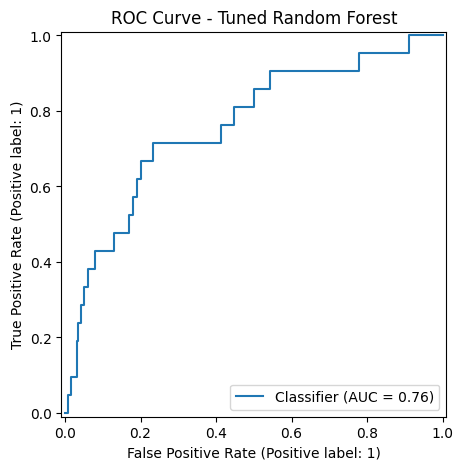

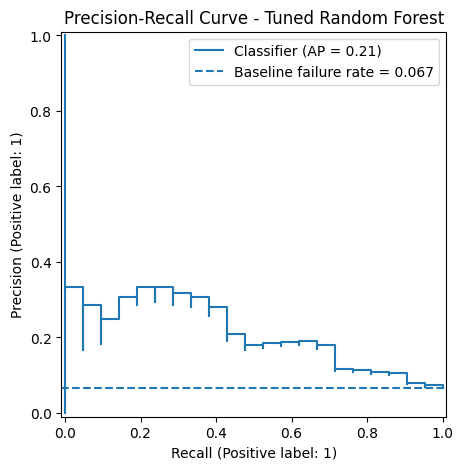

In [89]:
# Plot ROC and Precision-Recall curves for tuned RF on holdout test set

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax
)

ax.set_title("ROC Curve - Tuned Random Forest")
plt.show()


fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax
)

ax.axhline(
    y=y_test.mean(),
    linestyle="--",
    label=f"Baseline failure rate = {y_test.mean():.3f}"
)

ax.set_title("Precision-Recall Curve - Tuned Random Forest")
ax.legend()
plt.show()

### Fitting the best tuned model on all the training data and running a threshold sweep to identify the optimum cutoff for failed wafers

In [90]:
def threshold_sweep_from_proba(y_true, y_proba, thresholds):
    baseline_failure_rate = y_true.mean()
    results = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)

        results.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "flagged": y_pred.sum(),
            "flagged_rate": y_pred.mean(),
            "enrichment": precision / baseline_failure_rate
        })

    return (
        pd.DataFrame(results)
        .sort_values("threshold", ascending=False)
        .reset_index(drop=True)
    )

In [91]:
def eval_threshold(best_pipe: Pipeline, thresholds: list[int], X_train: pd.DataFrame = X_train, 
                   y_train: pd.DataFrame = y_train) -> pd.DataFrame:
    cv_proba = cross_val_predict(
        best_pipe,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    return threshold_sweep_from_proba(
        y_true=y_train,
        y_proba=cv_proba,
        thresholds=thresholds
    )

In [92]:
thresholds = np.arange(0.01, 0.51, 0.01)
cv_threshold_df = eval_threshold(best_pipe=best_pipe, thresholds=thresholds)
cv_threshold_df.round(3)

,threshold,precision,recall,f1,flagged,flagged_rate,enrichment
0,0.50,0.233,0.120,0.159,43,0.034,3.511
1,0.49,0.229,0.133,0.168,48,0.038,3.460
2,0.48,0.214,0.145,0.173,56,0.045,3.235
3,0.47,0.265,0.217,0.238,68,0.054,3.996
4,0.46,0.257,0.229,0.242,74,0.059,3.876
5,0.45,0.241,0.253,0.247,87,0.069,3.644
6,0.44,0.235,0.277,0.254,98,0.078,3.543
7,0.43,0.236,0.301,0.265,106,0.085,3.560
8,0.42,0.222,0.337,0.268,126,0.101,3.355
9,0.41,0.201,0.349,0.256,144,0.115,3.040


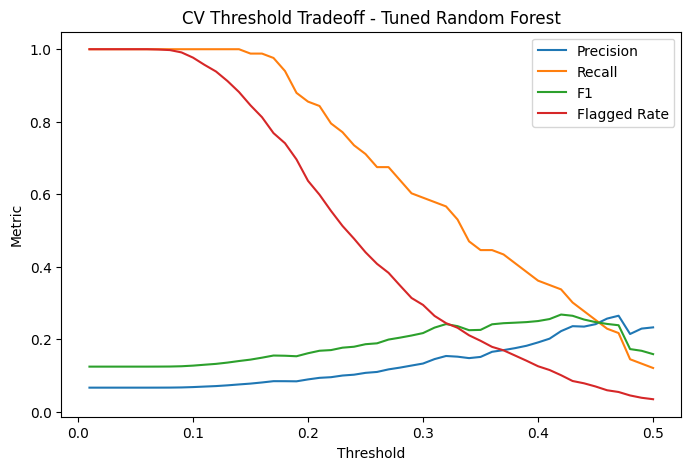

In [93]:
# Plotting threshold analysis results
plt.figure(figsize=(8, 5))

plt.plot(cv_threshold_df["threshold"], cv_threshold_df["precision"], label="Precision")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["recall"], label="Recall")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["f1"], label="F1")
plt.plot(cv_threshold_df["threshold"], cv_threshold_df["flagged_rate"], label="Flagged Rate")

plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("CV Threshold Tradeoff - Tuned Random Forest")
plt.legend()
plt.show()

In [94]:
# Selected threshold for max performance: The final threshold was selected using the maximum F1 score from out-of-fold training predictions.
selected_threshold = cv_threshold_df.loc[cv_threshold_df["f1"].idxmax(), "threshold"]

In [95]:
# Final model performance evaluation
def eval_test_final(best_pipe: Pipeline, selected_threshold: int, X_train: pd.DataFrame = X_train, y_train: pd.DataFrame = y_train,
                    X_test: pd.DataFrame = X_test, y_test: pd.DataFrame = y_test):
    
    best_pipe.fit(X_train, y_train)
    test_proba = best_pipe.predict_proba(X_test)[:, 1]

    return threshold_sweep_from_proba(
        y_true=y_test,
        y_proba=test_proba,
        thresholds=[selected_threshold]
    )

In [96]:
# Run final model performance evaluation
eval_test_final_df = eval_test_final(best_pipe=best_pipe, selected_threshold=selected_threshold)
eval_test_final_df

,threshold,precision,recall,f1,flagged,flagged_rate,enrichment
0,0.42,0.285714,0.285714,0.285714,21,0.066879,4.272109


In [97]:
final_model_summary = pd.concat([best_params_df, eval_test_final_df], axis=1)
final_model_summary

,best_model,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,cv_pr_auc,test_pr_auc,test_roc_auc,threshold,precision,recall,f1,flagged,flagged_rate,enrichment
0,Random Forest (small),20,10,0.1,12,0.236,0.214,0.759,0.42,0.285714,0.285714,0.285714,21,0.066879,4.272109


___

### Assessing feature importance in the best model

In [98]:
# Cloning the best pipe for clarity
final_pipe = clone(best_pipe)
final_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,missing_threshold,0.9
,corr_threshold,0.95
Name,Type,Value
corr_cols_,list,"['At...28', 'At...37', 'At...97', 'At...05', ...]"
feature_names_out_,list,"['At... 1', 'At... 2', 'At... 3', 'At... 4', ...]"


In [99]:
feature_importances = final_pipe.named_steps["model"].feature_importances_
feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "sensor": feature_names,
    "feature_importance": feature_importances
    }).sort_values("feature_importance", ascending=False)

feature_importance_df.head(20)

,sensor,feature_importance
93,Attribute 104,0.047490
52,Attribute 60,0.042538
30,Attribute 34,0.029769
116,Attribute 131,0.021289
28,Attribute 32,0.020707
178,Attribute 214,0.019200
195,Attribute 248,0.017726
172,Attribute 206,0.016893
247,Attribute 511,0.013175
57,Attribute 65,0.012795


In [100]:
perm = permutation_importance(
    final_pipe,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [101]:
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head(20)

,feature,importance_mean,importance_std
59,Attribute 60,0.058931,0.012486
21,Attribute 22,0.011883,0.004915
205,Attribute 206,0.010899,0.012204
33,Attribute 34,0.008731,0.009237
202,Attribute 203,0.008195,0.002098
131,Attribute 132,0.007733,0.004731
160,Attribute 161,0.007287,0.004906
197,Attribute 198,0.007103,0.004304
316,Attribute 317,0.007049,0.004064
431,Attribute 432,0.006667,0.003984


Text(0.5, 1.0, 'Top Features by RF Importance')

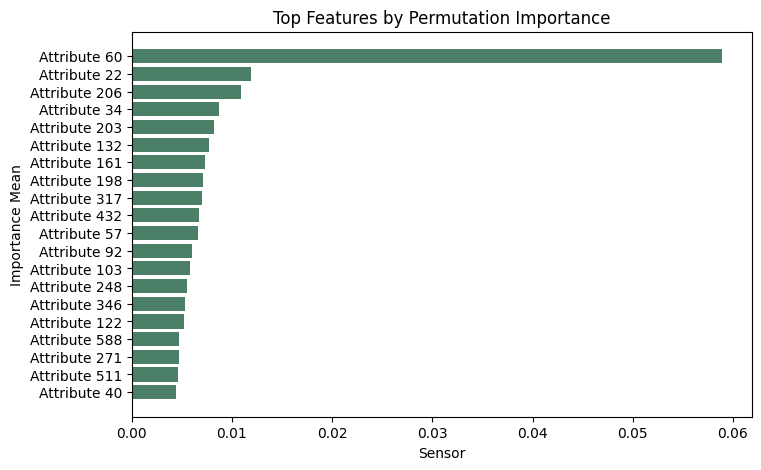

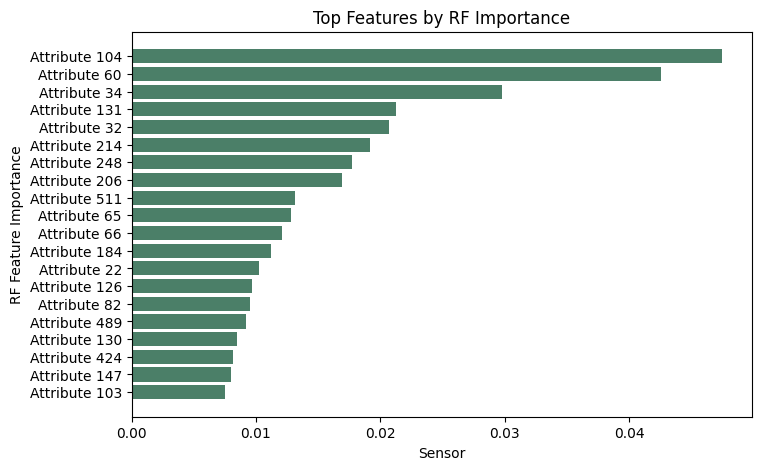

In [102]:
top_features_perm = perm_df[:20].sort_values("importance_mean")
plt.subplots(figsize=(8,5))
plt.barh(top_features_perm["feature"], top_features_perm["importance_mean"], color="#4B7F68")
plt.xlabel("Sensor")
plt.ylabel("Importance Mean")
plt.title("Top Features by Permutation Importance")

top_features_rf = feature_importance_df[:20].sort_values("feature_importance")
plt.subplots(figsize=(8,5))
plt.barh(top_features_rf["sensor"], top_features_rf["feature_importance"], color="#4B7F68")
plt.xlabel("Sensor")
plt.ylabel("RF Feature Importance")
plt.title("Top Features by RF Importance")

In [103]:
# Evaluating feature importance using cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

top_features = []
all_fold_importances = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

    X_fold = X_train.iloc[train_idx]
    y_fold = y_train.iloc[train_idx]

    pipe = clone(best_pipe)
    pipe.fit(X_fold, y_fold)

    rf = pipe.named_steps["model"]

    feature_names = (
        pipe
        .named_steps["preprocess"]
        .get_feature_names_out()
    )

    fold_importance = pd.DataFrame({
        "fold": fold,
        "feature": feature_names,
        "importance": rf.feature_importances_
    })

    all_fold_importances.append(fold_importance)

    top20 = (
        fold_importance
        .sort_values("importance", ascending=False)
        .head(20)
    )

    top_features.extend(top20["feature"])

In [104]:
feature_stability_df = (
    pd.Series(top_features)
    .value_counts()
    .reset_index()
)

feature_stability_df.columns = ["feature", "top20_fold_count"]

feature_stability_df.head(30)

,feature,top20_fold_count
0,Attribute 34,5
1,Attribute 104,5
2,Attribute 60,5
3,Attribute 131,5
4,Attribute 32,5
5,Attribute 248,5
6,Attribute 65,5
7,Attribute 214,5
8,Attribute 206,4
9,Attribute 511,4


In [105]:
# Summarizing feature importance explorations
rf_top20 = set(feature_importance_df.head(20)["sensor"])

perm_top20 = set(perm_df.head(20)["feature"])

stable_features = set(
    feature_stability_df[
        feature_stability_df["top20_fold_count"] >= 4
    ]["feature"]
)

all_features = rf_top20 | perm_top20 | stable_features

consensus_df = pd.DataFrame({
    "feature": sorted(all_features)
})

consensus_df["rf_top20"] = consensus_df["feature"].isin(rf_top20)
consensus_df["perm_top20"] = consensus_df["feature"].isin(perm_top20)
consensus_df["stable"] = consensus_df["feature"].isin(stable_features)

consensus_df["score"] = (
    consensus_df["rf_top20"].astype(int)
    + consensus_df["perm_top20"].astype(int)
    + consensus_df["stable"].astype(int)
)

consensus_df = consensus_df.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

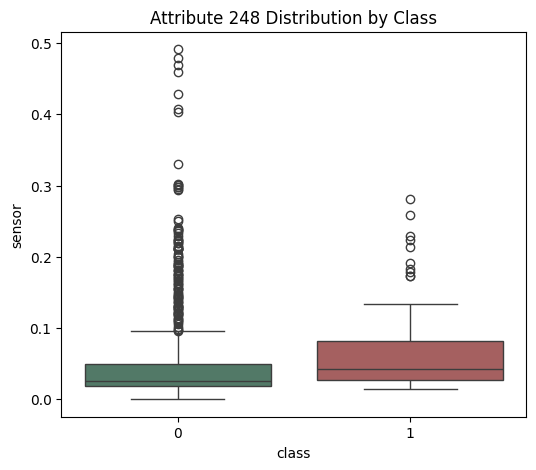

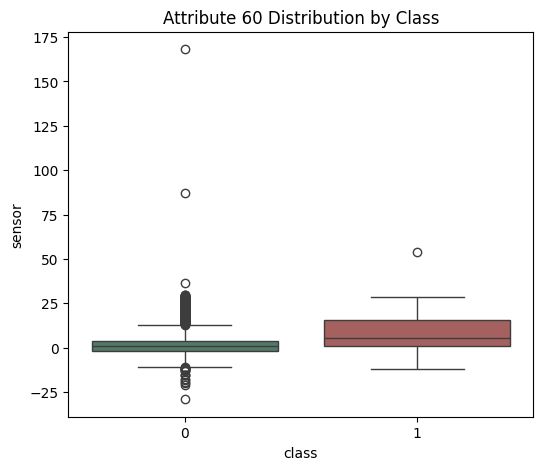

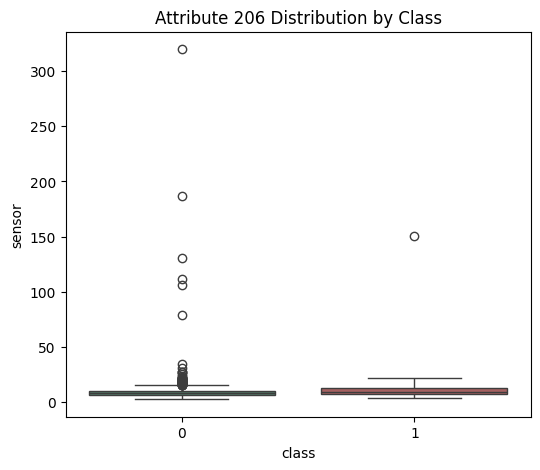

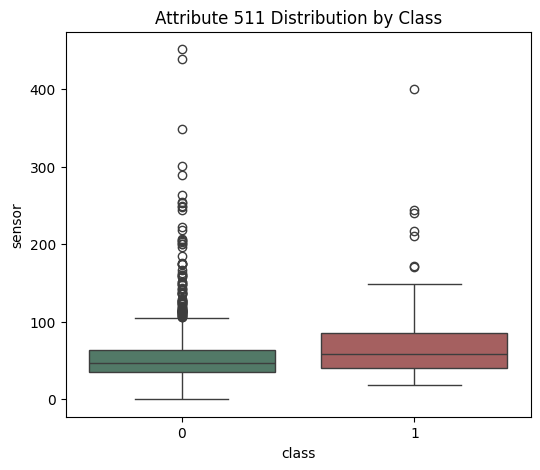

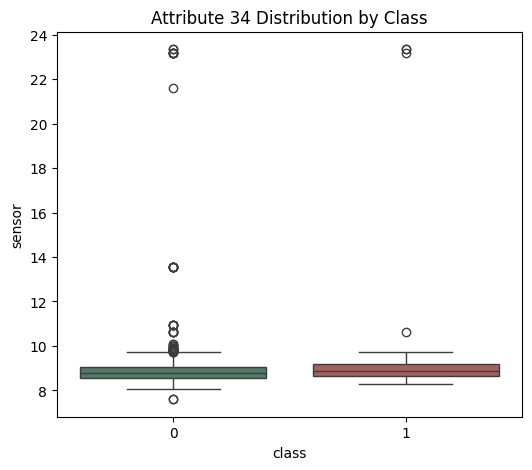

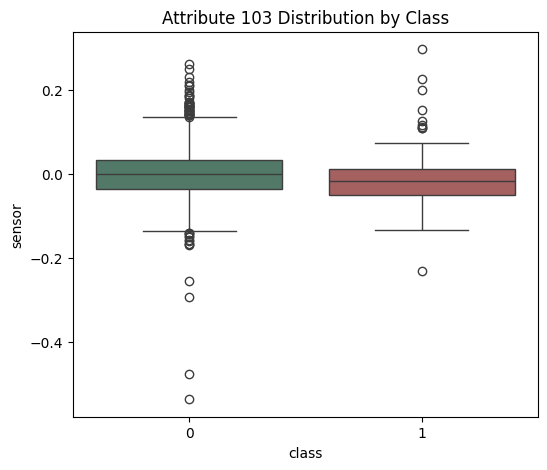

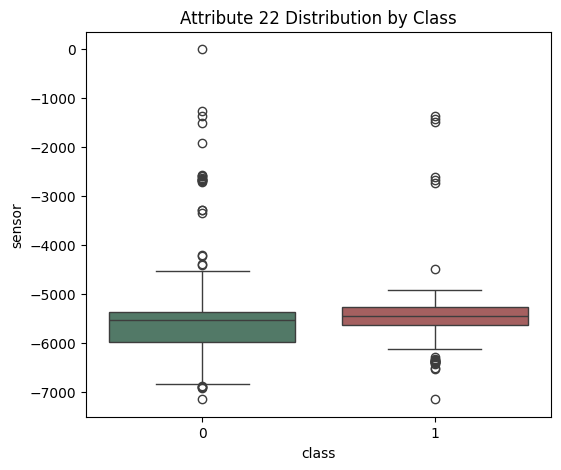

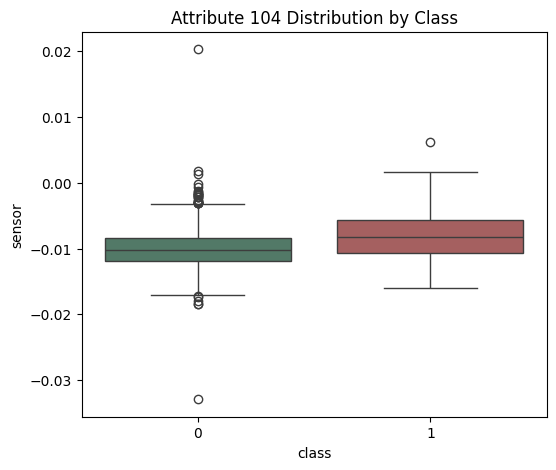

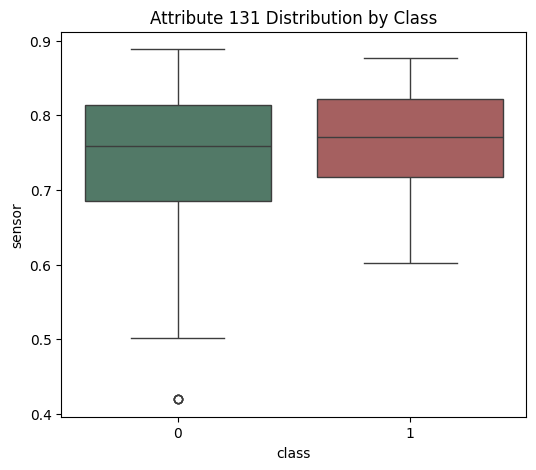

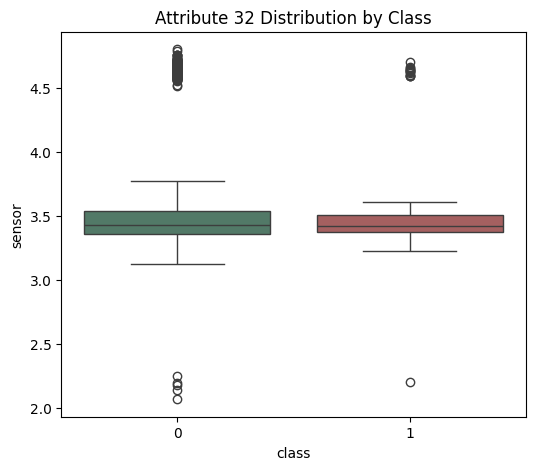

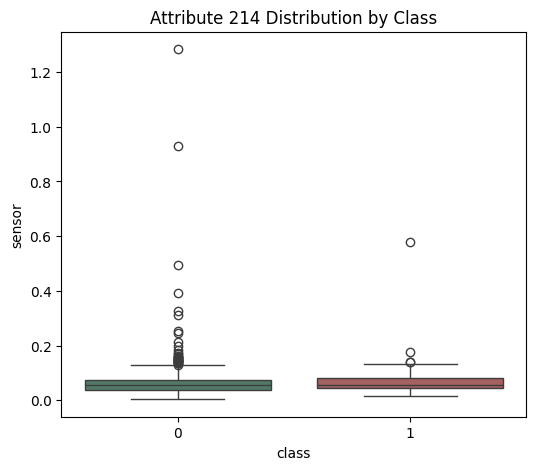

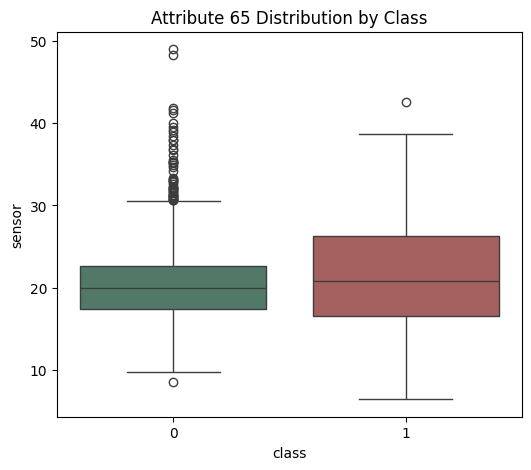

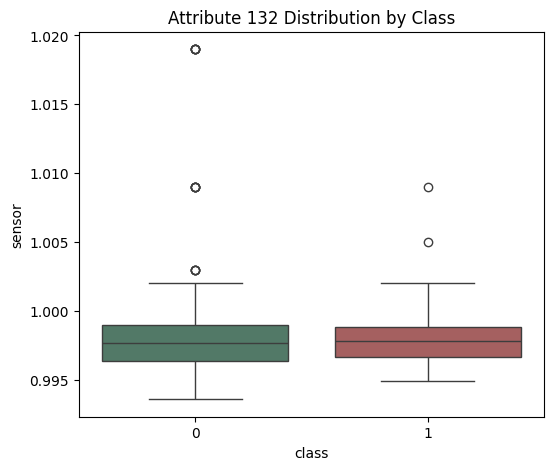

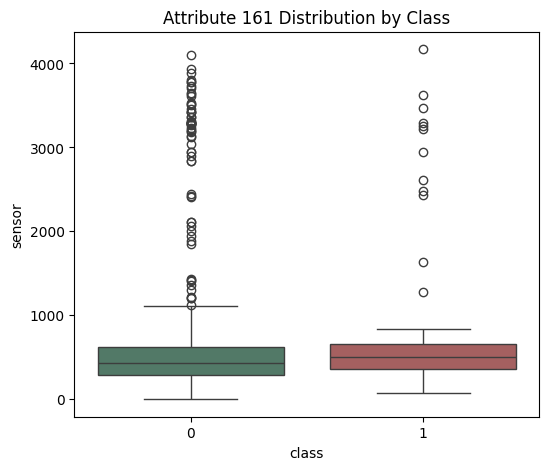

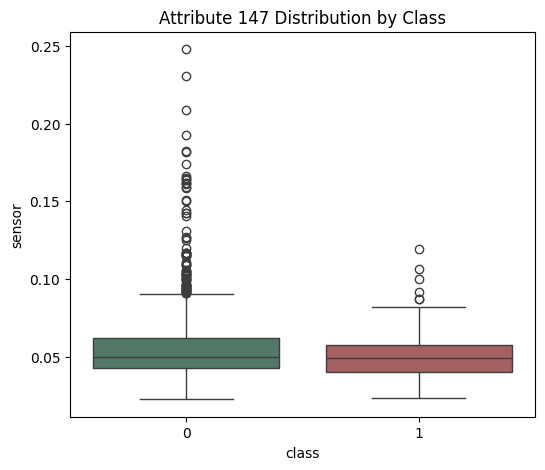

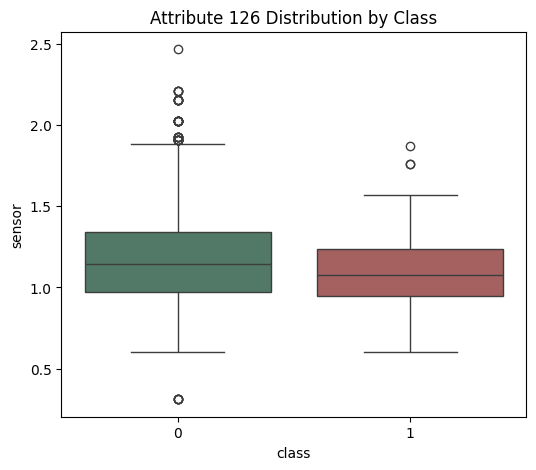

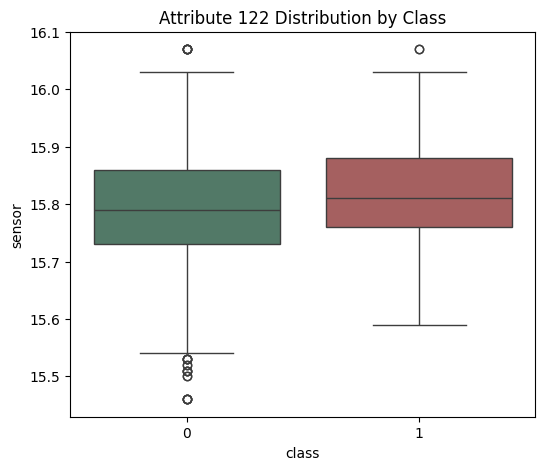

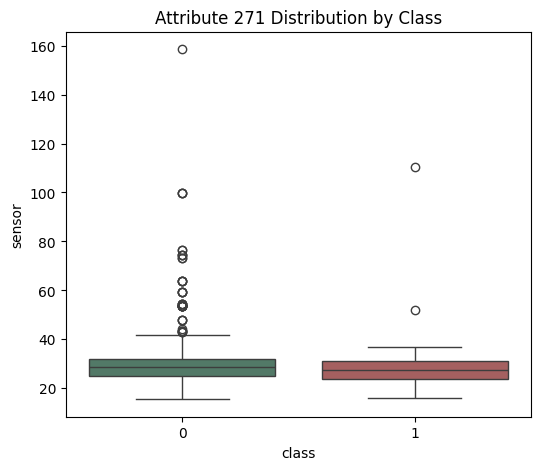

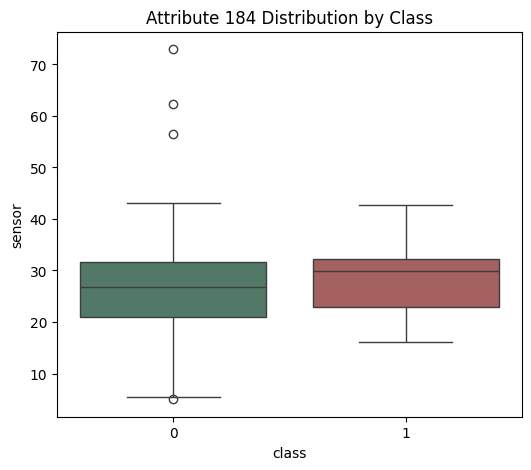

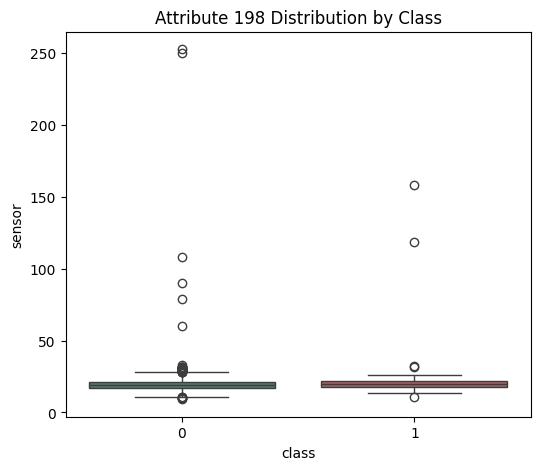

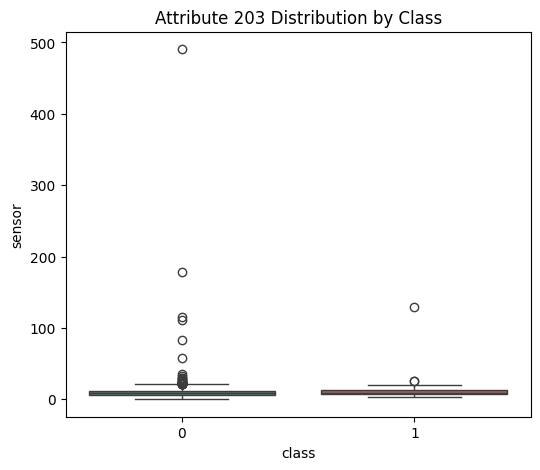

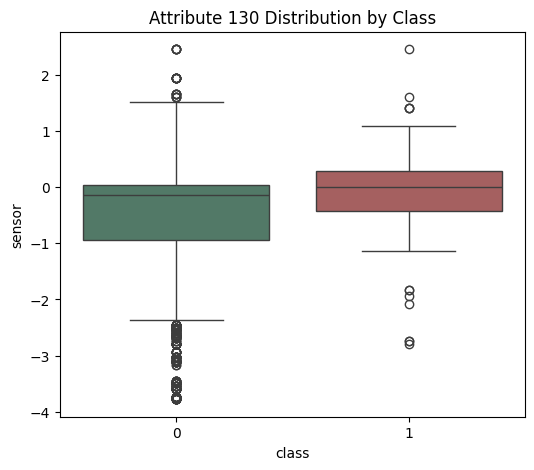

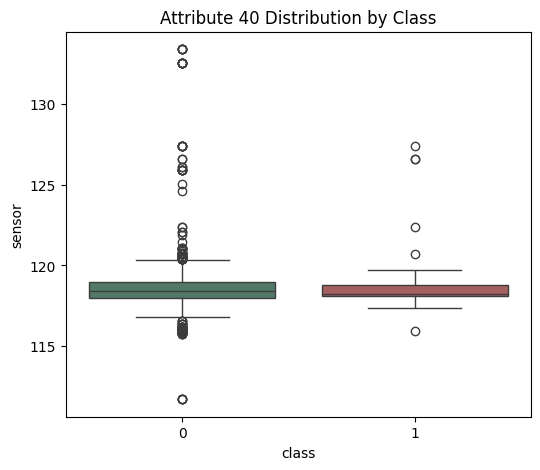

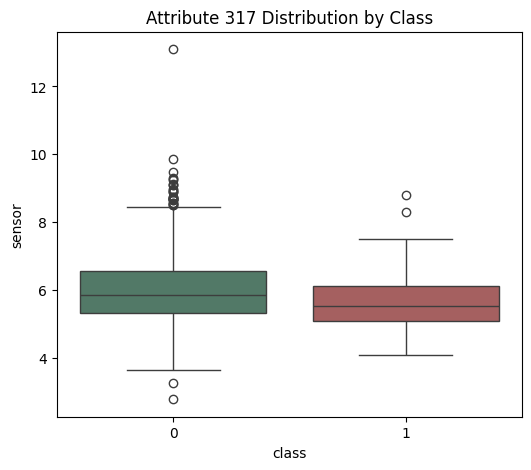

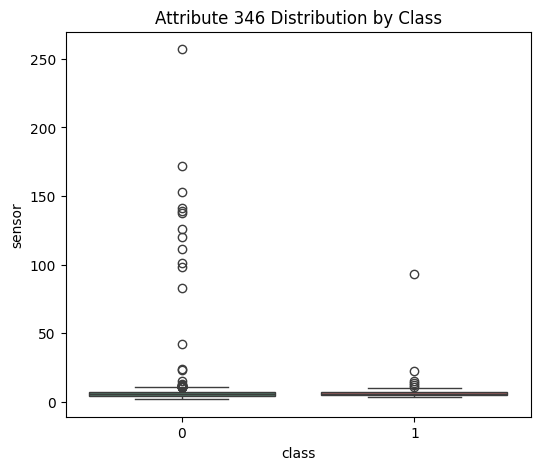

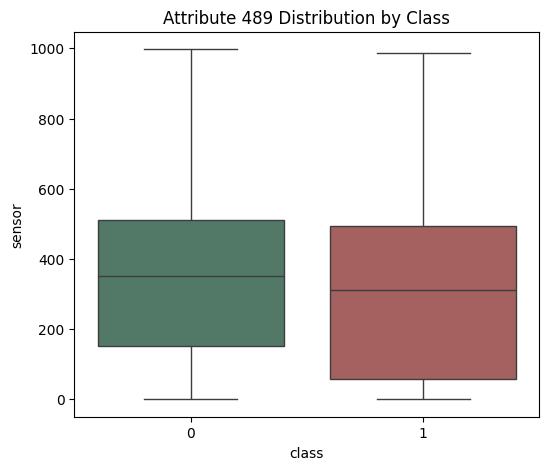

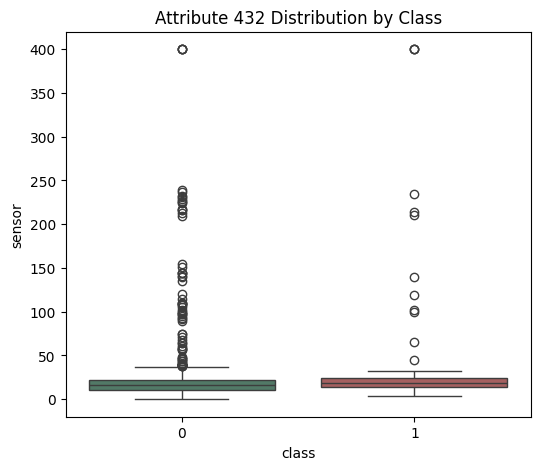

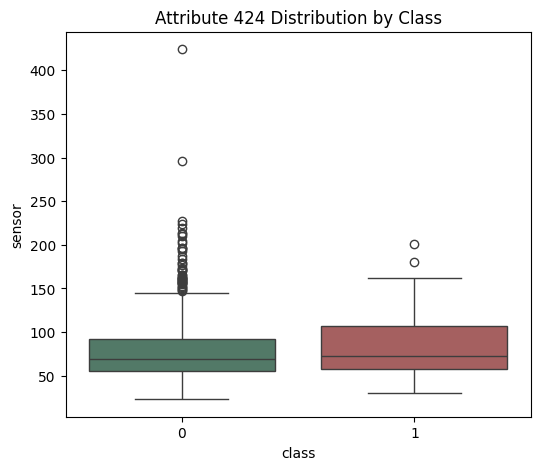

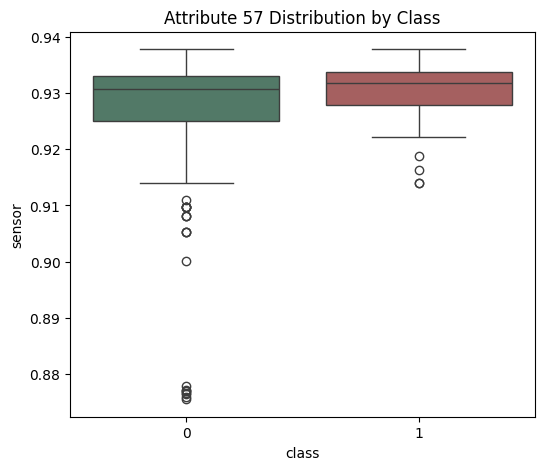

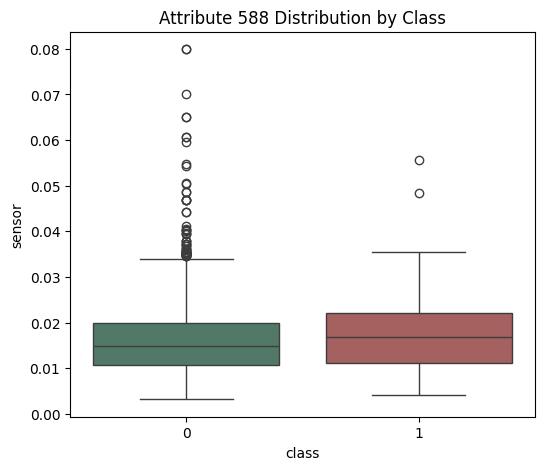

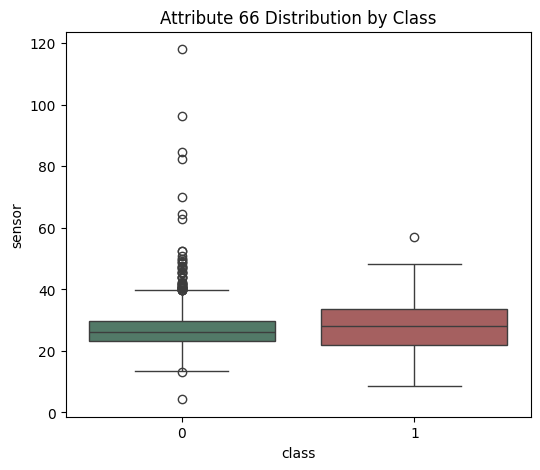

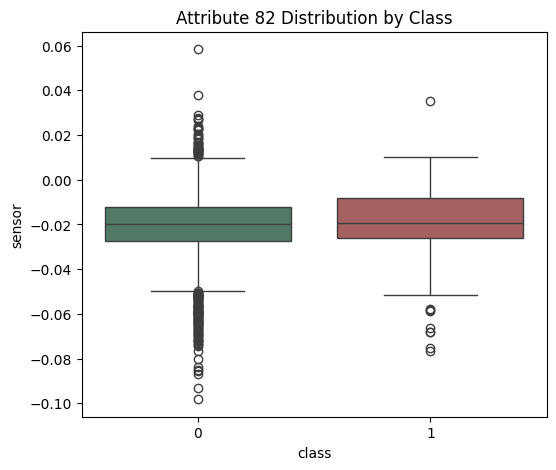

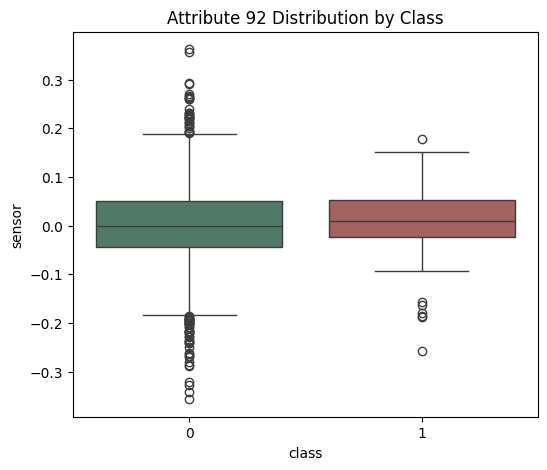

In [106]:
# Generating plots of the pass/fails by these top sensors

# Create boxplots of sensors
for sensor in consensus_df["feature"]:

    plot_df = pd.DataFrame({
        "sensor": X[sensor],
        "class": y
    })

    plt.figure(figsize=(6,5))

    sns.boxplot(
        data=plot_df,
        x="class",
        y="sensor",
        hue="class",
        palette={
            0: "#4B7F68",   # Pass
            1: "#B15455"    # Fail
        },
        legend=False
    )

    plt.title(f"{sensor} Distribution by Class")
    plt.show()

### Re-training the RF on only the top sensors to check performance

In [107]:
# reduced model loop to check cv performance of top sensors

def run_reduced_model(pipe, consensus_df, X=X, y=y):
    X_full = X.copy()

    results = []

    max_reduced_features = len(consensus_df)    

    for num_features in range(1, max_reduced_features + 1):
        # Key features
        key_features = consensus_df["feature"].head(num_features).to_list()
        X_red = X_full[key_features].copy()

        # Splitting data into training and testing sets
        X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
            X_red,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        scores = cross_validate(
            clone(pipe),
            X_train_red,
            y_train_red,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "pr_auc": "average_precision"
            },
            return_train_score=True,
            n_jobs=-1
        )

        results.append({
            "model": f"RF (Top {num_features} Features)",
            "train_col_check": len(X_red.columns),
            "train_roc_auc": scores["train_roc_auc"].mean(),
            "train_pr_auc": scores["train_pr_auc"].mean(),
            "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
            "cv_roc_auc_std": scores["test_roc_auc"].std(),
            "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
            "cv_pr_auc_std": scores["test_pr_auc"].std(),
        })
    return pd.DataFrame(results).round(3)    

In [108]:
# running the reduced model processing function
pipe_reduced = clone(best_pipe)
reduced_model_results = run_reduced_model(pipe=pipe_reduced, consensus_df=consensus_df)

In [109]:
# displating the results of the reduced model
reduced_model_results.sort_values("cv_pr_auc_mean", ascending=False).reset_index(drop=True)

,model,train_col_check,train_roc_auc,train_pr_auc,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,RF (Top 30 Features),30,0.999,0.990,0.801,0.043,0.317,0.040
1,RF (Top 27 Features),27,0.999,0.986,0.802,0.046,0.314,0.041
2,RF (Top 23 Features),23,0.998,0.970,0.786,0.038,0.313,0.039
3,RF (Top 19 Features),19,0.996,0.955,0.800,0.036,0.310,0.062
4,RF (Top 18 Features),18,0.995,0.939,0.782,0.043,0.310,0.071
5,RF (Top 21 Features),21,0.998,0.964,0.784,0.040,0.309,0.045
6,RF (Top 32 Features),32,0.999,0.990,0.794,0.048,0.306,0.042
7,RF (Top 26 Features),26,0.999,0.989,0.799,0.048,0.304,0.033
8,RF (Top 20 Features),20,0.997,0.962,0.782,0.037,0.301,0.036
9,RF (Top 28 Features),28,0.999,0.988,0.799,0.038,0.301,0.032


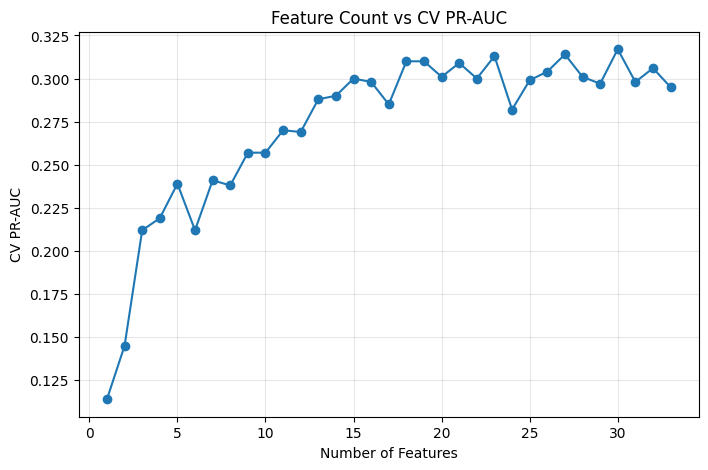

In [110]:
# plotting the cross-validated pr-auc as a function of the number of sensors included in the model
plt.figure(figsize=(8,5))

plt.plot(
    reduced_model_results["train_col_check"],
    reduced_model_results["cv_pr_auc_mean"],
    marker="o"
)

plt.xlabel("Number of Features")
plt.ylabel("CV PR-AUC")
plt.title("Feature Count vs CV PR-AUC")

plt.grid(alpha=0.3)

plt.show()

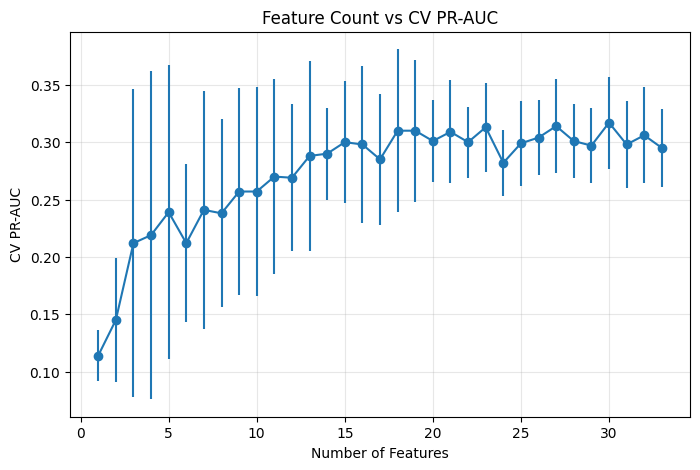

In [111]:
# adding error bars to the above plot
plt.figure(figsize=(8,5))

plt.errorbar(
    reduced_model_results["train_col_check"],
    reduced_model_results["cv_pr_auc_mean"],
    yerr=reduced_model_results["cv_pr_auc_std"],
    fmt="o-"
)

plt.xlabel("Number of Features")
plt.ylabel("CV PR-AUC")
plt.title("Feature Count vs CV PR-AUC")

plt.grid(alpha=0.3)

plt.show()

In [112]:
# since reduced model showed promise, creating a function to check different feature counts at various thresholds, then evaluating the best feature_counts
# at the best threshold on a hold out set once for final performance
def run_reduced_model_test(
    final_reduced_pipe,
    consensus_df,
    num_features,
    thresholds,
    cv,
    X=X,
    y=y
):
    X_full = X.copy()

    key_features = consensus_df["feature"].head(num_features).to_list()
    X_red = X_full[key_features].copy()

    X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
        X_red,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # -----------------------------
    # 1. Choose threshold using OOF training predictions only
    # -----------------------------
    oof_proba = cross_val_predict(
        clone(final_reduced_pipe),
        X_train_red,
        y_train_red,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold_results = []

    baseline_train_failure_rate = y_train_red.mean()

    for threshold in thresholds:
        y_oof_pred = (oof_proba >= threshold).astype(int)

        threshold_results.append({
            "num_features": num_features,
            "threshold": threshold,
            "oof_pr_auc": average_precision_score(y_train_red, oof_proba),
            "oof_roc_auc": roc_auc_score(y_train_red, oof_proba),
            "oof_precision": precision_score(y_train_red, y_oof_pred, zero_division=0),
            "oof_recall": recall_score(y_train_red, y_oof_pred, zero_division=0),
            "oof_f1": f1_score(y_train_red, y_oof_pred, zero_division=0),
            "oof_flagged": y_oof_pred.sum(),
            "oof_flagged_rate": y_oof_pred.mean(),
            "oof_enrichment": precision_score(y_train_red, y_oof_pred, zero_division=0) / baseline_train_failure_rate
        })

    threshold_df = pd.DataFrame(threshold_results)

    best_threshold = (
        threshold_df
        .sort_values("oof_f1", ascending=False)
        .iloc[0]["threshold"]
    )

    # -----------------------------
    # 2. Fit final model on full training set
    # -----------------------------
    final_model = clone(final_reduced_pipe)
    final_model.fit(X_train_red, y_train_red)

    # -----------------------------
    # 3. Evaluate once on holdout test set
    # -----------------------------
    test_proba = final_model.predict_proba(X_test_red)[:, 1]
    test_pred = (test_proba >= best_threshold).astype(int)

    baseline_test_failure_rate = y_test_red.mean()
    test_precision = precision_score(y_test_red, test_pred, zero_division=0)

    test_results = pd.DataFrame([{
        "model": f"RF (Top {num_features} Features)",
        "num_features": num_features,
        "selected_threshold": best_threshold,
        "test_pr_auc": average_precision_score(y_test_red, test_proba),
        "test_roc_auc": roc_auc_score(y_test_red, test_proba),
        "precision": test_precision,
        "recall": recall_score(y_test_red, test_pred, zero_division=0),
        "f1": f1_score(y_test_red, test_pred, zero_division=0),
        "flagged": test_pred.sum(),
        "flagged_rate": test_pred.mean(),
        "enrichment": test_precision / baseline_test_failure_rate
    }])

    return (
        test_results.round(3),
        threshold_df.sort_values("oof_f1", ascending=False).round(3),
        final_model,
        key_features
    )

In [113]:
# running the function from above with num_features of 30
final_reduced_pipe = clone(best_pipe)
thresholds = np.arange(0.01, 1.00, 0.01)

reduced_model_test_perf, reduced_threshold_df, final_reduced_model, key_features = run_reduced_model_test(
    final_reduced_pipe=final_reduced_pipe,
    consensus_df=consensus_df,
    num_features=30,
    thresholds=thresholds,
    cv=cv
)

In [114]:
# checking the best threshold for the num_featurres of 30 test based on test results
reduced_model_test_perf

,model,num_features,selected_threshold,test_pr_auc,test_roc_auc,precision,recall,f1,flagged,flagged_rate,enrichment
0,RF (Top 30 Features),30,0.54,0.251,0.753,0.286,0.19,0.229,14,0.045,4.272


In [115]:
# checking the actual threshold level data for trends
reduced_threshold_df.head(10)

,num_features,threshold,oof_pr_auc,oof_roc_auc,oof_precision,oof_recall,oof_f1,oof_flagged,oof_flagged_rate,oof_enrichment
53,30,0.54,0.275,0.801,0.372,0.386,0.379,86,0.069,5.617
52,30,0.53,0.275,0.801,0.340,0.398,0.367,97,0.077,5.136
51,30,0.52,0.275,0.801,0.317,0.398,0.353,104,0.083,4.790
54,30,0.55,0.275,0.801,0.354,0.337,0.346,79,0.063,5.351
50,30,0.51,0.275,0.801,0.298,0.410,0.345,114,0.091,4.502
49,30,0.50,0.275,0.801,0.279,0.410,0.332,122,0.097,4.207
56,30,0.57,0.275,0.801,0.368,0.301,0.331,68,0.054,5.550
48,30,0.49,0.275,0.801,0.269,0.422,0.329,130,0.104,4.064
57,30,0.58,0.275,0.801,0.397,0.277,0.326,58,0.046,5.986
55,30,0.56,0.275,0.801,0.347,0.301,0.323,72,0.057,5.242


In [116]:
# sweeping the above threshold analysis across different top feature counts
feature_counts = [15, 20, 25, 30]

all_holdout_results = []
all_threshold_results = {}

for n in feature_counts:
    test_result, threshold_df, final_model, key_features = run_reduced_model_test(
        final_reduced_pipe=clone(best_pipe),
        consensus_df=consensus_df,
        num_features=n,
        thresholds=np.arange(0.01, 1.00, 0.01),
        cv=cv
    )

    all_holdout_results.append(test_result)

    all_threshold_results[n] = {
        "threshold_df": threshold_df,
        "final_model": final_model,
        "key_features": key_features
    }

reduced_holdout_comparison = (
    pd.concat(all_holdout_results, ignore_index=True)
    .sort_values("test_pr_auc", ascending=False)
)

In [117]:
# checking best feature count / threshold combos
reduced_holdout_comparison

,model,num_features,selected_threshold,test_pr_auc,test_roc_auc,precision,recall,f1,flagged,flagged_rate,enrichment
2,RF (Top 25 Features),25,0.55,0.253,0.789,0.250,0.143,0.182,12,0.038,3.738
3,RF (Top 30 Features),30,0.54,0.251,0.753,0.286,0.190,0.229,14,0.045,4.272
1,RF (Top 20 Features),20,0.50,0.215,0.768,0.250,0.381,0.302,32,0.102,3.738
0,RF (Top 15 Features),15,0.54,0.215,0.765,0.241,0.333,0.280,29,0.092,3.609


In [118]:
# looking into the 25 feature count theshold level data
all_threshold_results[25]["threshold_df"].head(15)

,num_features,threshold,oof_pr_auc,oof_roc_auc,oof_precision,oof_recall,oof_f1,oof_flagged,oof_flagged_rate,oof_enrichment
54,25,0.55,0.269,0.786,0.309,0.349,0.328,94,0.075,4.657
55,25,0.56,0.269,0.786,0.314,0.325,0.320,86,0.069,4.740
53,25,0.54,0.269,0.786,0.287,0.349,0.315,101,0.081,4.335
49,25,0.50,0.269,0.786,0.248,0.422,0.312,141,0.113,3.747
52,25,0.53,0.269,0.786,0.270,0.361,0.309,111,0.089,4.080
51,25,0.52,0.269,0.786,0.261,0.373,0.307,119,0.095,3.933
50,25,0.51,0.269,0.786,0.252,0.386,0.305,127,0.101,3.804
44,25,0.45,0.269,0.786,0.214,0.530,0.304,206,0.164,3.224
48,25,0.49,0.269,0.786,0.234,0.434,0.304,154,0.123,3.529
57,25,0.58,0.269,0.786,0.333,0.277,0.303,69,0.055,5.032


### Final Remarks


This project evaluated the ability to predict manufacturing failures using the UCI SECOM semiconductor process dataset. The dataset contains 1,567 wafers, 590 process sensors, and a failure rate of approximately 6.6%.

A leakage-safe preprocessing pipeline was developed to handle missing values, remove zero-variance sensors, and eliminate highly correlated features within each cross-validation fold. This ensured that all model evaluation reflected realistic out-of-sample performance.

Several classification approaches were explored, including regularized logistic regression, random forests, gradient boosting methods, and feature reduction strategies. Tree-based ensemble models consistently outperformed linear models, indicating that failure behavior is driven by nonlinear relationships that cannot be captured well by simple linear decision boundaries.

Feature importance was evaluated using impurity importance, permutation importance, and cross-validation stability analysis. These results were combined into a consensus ranking that identified a relatively small set of sensors that repeatedly demonstrated predictive value across multiple evaluation methods.

One of the most important findings was that reducing the feature space improved model performance. The strongest reduced model used only 25 sensors and achieved a holdout PR-AUC of 0.253 and a holdout ROC-AUC of 0.789. This exceeded the performance of the full-feature model while using substantially fewer process variables.

The results suggest that most of the predictive information is concentrated within a relatively small subset of sensors. Additional sensors appear to contribute more noise than useful signal, increasing model variance and reducing generalization performance.

Threshold optimization was performed using out-of-fold predictions from the training set to avoid information leakage. Depending on the selected operating point, the final model was able to identify wafers with failure rates more than four times higher than the baseline failure rate of the dataset.

Overall, the project demonstrates that meaningful failure prediction is possible on the SECOM dataset and that careful feature selection can improve both model simplicity and predictive performance. The final model provides evidence that manufacturing failures are associated with a limited set of interacting process signals rather than broad patterns distributed across hundreds of sensors.
